<a href="https://colab.research.google.com/github/xiny87/Diabetes-ML-Project/blob/main/healthcare_ml_diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Risk Prediction with Machine Learning

**Author:** Xin Anne Yuan  
**Tools:** Python, pandas, scikit-learn, Google Colab  

This project builds machine learning models to predict diabetes risk using patient-level clinical data.  
The analysis is based on the Pima Indians Diabetes dataset, a commonly used dataset for healthcare machine learning studies.

The notebook demonstrates a typical healthcare data science workflow including exploratory data analysis (EDA), clinically informed feature engineering, predictive modeling, and model interpretation.

---

## Project Objective

The goal of this project is to develop baseline machine learning models to identify factors associated with diabetes risk and evaluate their predictive performance.

This notebook demonstrates:

- data loading and inspection  
- exploratory data analysis (EDA)  
- feature engineering based on clinical intuition  
- baseline predictive modeling  
- model evaluation using ROC-AUC  
- model interpretation and feature importance analysis  

---

## Models Used

Logistic Regression  
Random Forest  

---

## Evaluation Metric

ROC-AUC

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

## 1. Load Data
We use the Pima Indians Diabetes dataset, a commonly used dataset for healthcare machine learning practice.

In [31]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Data Inspection
We first examine the structure, missing values, and summary statistics of the dataset.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [33]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [34]:
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 3. Exploratory Data Analysis
We explore the target distribution and inspect several clinically relevant variables.

In [35]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [36]:
df["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


In [37]:
df.groupby("Outcome")[["Glucose", "BMI", "Age", "Insulin"]].mean()

,Glucose,BMI,Age,Insulin
Outcome,,,,
0,109.980000,30.304200,31.190000,68.792000
1,141.257463,35.142537,37.067164,100.335821


Patients with diabetes outcome = 1 tend to have higher average glucose, BMI, and age, suggesting these variables may be important predictors.

## 4. Feature Engineering

In this section, we create clinically meaningful features that may improve model performance.

### Clinical intuition
- **is_elderly**: Older patients may have higher metabolic risk and more chronic disease burden.
- **high_bmi**: Obesity is a major risk factor for diabetes.
- **high_glucose**: Elevated glucose is directly associated with abnormal glycemic regulation.
- **metabolic_risk**: A combined score of glucose, blood pressure, and BMI may reflect overall metabolic stress.
- **pregnancy_age_interaction**: Pregnancy history may interact with age in influencing diabetes risk.

In [38]:
# Feature Engineering

# 1. Older age indicator
df["is_elderly"] = (df["Age"] >= 60).astype(int)

# 2. High BMI indicator
df["high_bmi"] = (df["BMI"] >= 30).astype(int)

# 3. High glucose indicator
df["high_glucose"] = (df["Glucose"] >= 140).astype(int)

# 4. Metabolic risk score
df["metabolic_risk"] = df["Glucose"] + df["BloodPressure"] + df["BMI"]

# 5. Pregnancy and age interaction
df["pregnancy_age_interaction"] = df["Pregnancies"] * df["Age"]

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,is_elderly,high_bmi,high_glucose,metabolic_risk,pregnancy_age_interaction
0,6,148,72,35,0,33.6,0.627,50,1,0,1,1,253.6,300
1,1,85,66,29,0,26.6,0.351,31,0,0,0,0,177.6,31
2,8,183,64,0,0,23.3,0.672,32,1,0,0,1,270.3,256
3,1,89,66,23,94,28.1,0.167,21,0,0,0,0,183.1,21
4,0,137,40,35,168,43.1,2.288,33,1,0,1,0,220.1,0


In [39]:
new_features = [
    "is_elderly",
    "high_bmi",
    "high_glucose",
    "metabolic_risk",
    "pregnancy_age_interaction"
]

df[new_features].head()

,is_elderly,high_bmi,high_glucose,metabolic_risk,pregnancy_age_interaction
0,0,1,1,253.6,300
1,0,0,0,177.6,31
2,0,0,1,270.3,256
3,0,0,0,183.1,21
4,0,1,0,220.1,0


## 5. Define Features and Target
The target variable is `Outcome`, where 1 indicates diabetes and 0 indicates no diabetes.

In [40]:
target = "Outcome"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 13)
y shape: (768,)


## 6. Train-Test Split
We split the data into training and testing sets to evaluate model performance on unseen data.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 13)
Testing set: (154, 13)


## 7. Baseline Logistic Regression Model
Logistic regression is used as a baseline interpretable model for binary classification.

In [42]:
model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

## 8. Model Evaluation
We evaluate model performance using ROC-AUC, confusion matrix, and a classification report.

In [43]:
pred_prob = model.predict_proba(X_test)[:, 1]
pred_label = model.predict(X_test)

auc = roc_auc_score(y_test, pred_prob)
print("Logistic Regression ROC-AUC:", round(auc, 3))

Logistic Regression ROC-AUC: 0.841


In [44]:
cm = confusion_matrix(y_test, pred_label)
cm

array([[82, 18],
       [25, 29]])

In [45]:
print(classification_report(y_test, pred_label))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79       100
           1       0.62      0.54      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.68       154
weighted avg       0.71      0.72      0.72       154



## 9. ROC Curve
The ROC curve shows the tradeoff between sensitivity and specificity across classification thresholds.

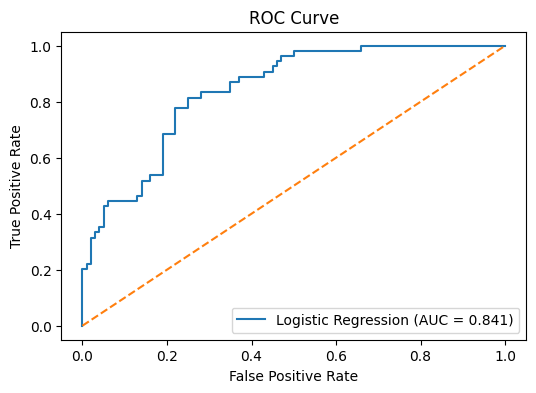

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, pred_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Model Interpretation
We inspect logistic regression coefficients to identify which variables are most strongly associated with diabetes risk in this baseline model.

In [47]:
coef_table = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
coef_table

,0
DiabetesPedigreeFunction,0.679361
high_bmi,0.617901
Pregnancies,0.265815
Age,0.053262
high_glucose,0.045301
BMI,0.037695
metabolic_risk,0.021350
Glucose,0.015320
SkinThickness,0.005889
Insulin,-0.001469


In [48]:
coef_table.head(10)

,0
DiabetesPedigreeFunction,0.679361
high_bmi,0.617901
Pregnancies,0.265815
Age,0.053262
high_glucose,0.045301
BMI,0.037695
metabolic_risk,0.021350
Glucose,0.015320
SkinThickness,0.005889
Insulin,-0.001469


### Logistic Regression Interpretation

The logistic regression model identified several clinically meaningful predictors of diabetes risk.

**DiabetesPedigreeFunction** showed the strongest association, which is consistent with the role of genetic predisposition in diabetes development.

**High BMI** was also strongly associated with diabetes risk, reflecting the well-established relationship between obesity and metabolic disease.

Other predictors such as **pregnancy history**, **age**, and **elevated glucose levels** also contributed to the model, aligning with known clinical risk factors.

## 11. Random Forest Model
To compare performance with a nonlinear model, we also train a random forest classifier.

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [22]:
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred_label = rf_model.predict(X_test)

rf_auc = roc_auc_score(y_test, rf_pred_prob)
print("Random Forest ROC-AUC:", round(rf_auc, 3))

Random Forest ROC-AUC: 0.81


### Random Forest Feature Importance

The random forest model highlighted **glucose-related variables** as the most important predictors.

**Glucose** and the engineered **metabolic risk score** ranked highest, suggesting that measures related to glycemic control and metabolic stress play a key role in diabetes prediction.

BMI and age also contributed substantially, which is consistent with established clinical risk factors for metabolic disorders.


In [23]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importance

,0
Glucose,0.221228
metabolic_risk,0.203871
BMI,0.098518
high_glucose,0.092170
Age,0.086531
DiabetesPedigreeFunction,0.066861
pregnancy_age_interaction,0.054463
Insulin,0.037971
BloodPressure,0.035831
Pregnancies,0.035079


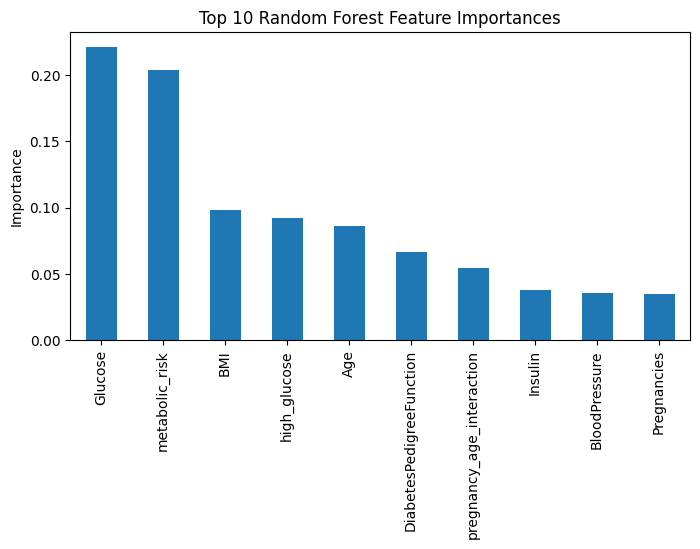

In [24]:
rf_importance.head(10).plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 Random Forest Feature Importances")
plt.ylabel("Importance")
plt.show()

## Model Performance: Confusion Matrix

The confusion matrix shows how well the model distinguishes between patients with and without diabetes.

This helps interpret the clinical implications of model predictions, including false positives and false negatives.

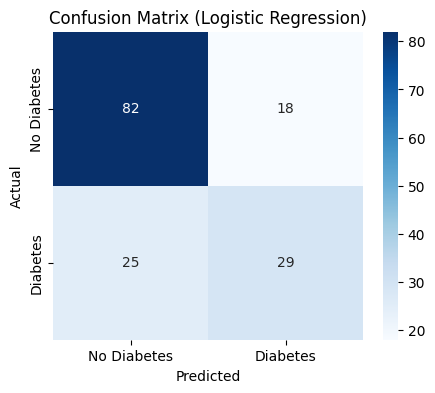

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_label)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes","Diabetes"],
    yticklabels=["No Diabetes","Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression)")

plt.show()

## Clinical Risk Stratification

To demonstrate potential clinical application, patients are stratified into three risk groups based on predicted probability:

Low risk  
Medium risk  
High risk

This approach is commonly used in healthcare risk prediction models.

In [28]:
risk_df = pd.DataFrame({
    "pred_prob": pred_prob,
    "actual": y_test.reset_index(drop=True)
})

risk_df["risk_group"] = pd.cut(
    risk_df["pred_prob"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df.head()

,pred_prob,actual,risk_group
0,0.602657,0,High Risk
1,0.119729,0,Low Risk
2,0.275514,0,Low Risk
3,0.250188,1,Low Risk
4,0.006833,0,Low Risk


In [29]:
risk_df.groupby("risk_group")["actual"].mean()

/tmp/ipykernel_162/3405283248.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("risk_group")["actual"].mean()


,actual
risk_group,
Low Risk,0.111111
Medium Risk,0.552632
High Risk,0.685714


### Risk Stratification Interpretation

Patients in the high-risk group show substantially higher observed diabetes prevalence compared to the low-risk group.

This suggests that the model can effectively stratify patients by predicted risk, which could potentially support targeted screening or preventive interventions in clinical settings.

## Key Findings

The models achieved good predictive performance (ROC-AUC ≈ 0.84), indicating strong discrimination between patients with and without diabetes.

Several clinically meaningful predictors were identified:

- Glucose levels were the most important predictor across models, consistent with its central role in diabetes diagnosis.
- Obesity-related variables such as BMI were strongly associated with diabetes risk.
- Age and family history (Diabetes Pedigree Function) also contributed to risk prediction.

The engineered metabolic risk feature also ranked among the top predictors, suggesting that incorporating clinically informed features can enhance model interpretability in healthcare machine learning applications.

## 13. Conclusion

In this project, I built baseline machine learning models to predict diabetes risk using patient-level clinical features.

Key steps included:
- exploratory data analysis
- clinically informed feature engineering
- baseline logistic regression modeling
- ROC-AUC evaluation
- random forest comparison
- feature importance interpretation

The engineered features such as **metabolic_risk**, **high_bmi**, and **high_glucose** were among the most important predictors, suggesting that clinically informed feature engineering can enhance model interpretability and predictive power.